# Day04 — Python + SQLite 맛보기

**JOIN 및 서브쿼리 심화** 수업용 Jupyter Notebook  
Python `sqlite3` 표준 라이브러리로 DB를 다루고, `matplotlib`으로 간단히 시각화합니다.

| 파트 | 내용 |
|------|------|
| 1 | `classicmodels.db` 연결 · 데이터 가져오기 |
| 2 | JOIN 결과 시각화 (`fig, ax = plt.subplots()`) |
| 3 | `datasets/`에 새 DB 생성 + CRUD |
| 4 | 가상 샘플 데이터 + JOIN · 서브쿼리 실행 |

---
## 0. 라이브러리 & 경로 설정

In [1]:
import sqlite3
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 한글 폰트 설정 (Windows: 맑은 고딕 / Mac: AppleGothic)
for font_name in ['Malgun Gothic', 'AppleGothic', 'NanumGothic']:
    if font_name in {f.name for f in fm.fontManager.ttflist}:
        plt.rcParams['font.family'] = font_name
        break
plt.rcParams['axes.unicode_minus'] = False

# 노트북 위치 기준 datasets 폴더 경로
BASE_DIR = Path('..') / '..' / 'datasets'
CLASSIC_DB = BASE_DIR / 'classicmodels.db'
PRACTICE_DB = BASE_DIR / 'day04_shop.db'   # 새로 만들 연습용 DB

print('classicmodels 경로:', CLASSIC_DB.resolve())
print('연습용 DB 경로  :', PRACTICE_DB.resolve())

classicmodels 경로: C:\yeardreamschool6th\datasets\classicmodels.db
연습용 DB 경로  : C:\yeardreamschool6th\datasets\day04_shop.db


---
## 1. `classicmodels.db` — sqlite3로 데이터 가져오기

`sqlite3.connect()` → `cursor.execute()` → `fetchall()` 패턴입니다.

In [2]:
def run_query(db_path, sql, params=()):
    """SQLite 쿼리 실행 후 (컬럼명 리스트, 행 리스트) 반환"""
    # MySQL 서버 연결, 서버주소 : 127.0.0.1, username, password, port번호 조합
    conn = sqlite3.connect(db_path)
    conn.row_factory = sqlite3.Row          # dict처럼 컬럼명으로 접근 가능
    cur = conn.cursor()
    cur.execute(sql, params)
    rows = cur.fetchall()
    columns = [desc[0] for desc in cur.description] if cur.description else []
    conn.close()
    return columns, rows


# 테이블 목록 확인
cols, tables = run_query(
    CLASSIC_DB,
    "SELECT name FROM sqlite_master WHERE type='table' ORDER BY name"
)
print('classicmodels 테이블:', [row[0] for row in tables])

classicmodels 테이블: ['customers', 'employees', 'offices', 'orderdetails', 'orders', 'payments', 'productlines', 'products']


In [3]:
# 국가별 고객 수 (GROUP BY 맛보기)
sql_customers = """
SELECT country, COUNT(*) AS customer_count
FROM customers
GROUP BY country
ORDER BY customer_count DESC
LIMIT 8
"""

cols, rows = run_query(CLASSIC_DB, sql_customers)
print(cols)
for row in rows:
    print(dict(row))

['country', 'customer_count']
{'country': 'USA', 'customer_count': 36}
{'country': 'Germany', 'customer_count': 13}
{'country': 'France', 'customer_count': 12}
{'country': 'Spain', 'customer_count': 7}
{'country': 'UK', 'customer_count': 5}
{'country': 'Australia', 'customer_count': 5}
{'country': 'New Zealand', 'customer_count': 4}
{'country': 'Italy', 'customer_count': 4}


In [4]:
# 제품 라인별 매출 (JOIN 맛보기)
sql_revenue = """
SELECT 
    p.productLine
    , ROUND(SUM(od.quantityOrdered * od.priceEach), 2) AS revenue
FROM orderdetails od 
INNER JOIN products p ON od.productCode = p.productCode
GROUP BY p.productLine
ORDER BY revenue DESC
;
"""

cols, revenue_rows = run_query(CLASSIC_DB, sql_revenue)
for row in revenue_rows:
    print(f"{row['productLine']:25s}  {row['revenue']:>12,.0f}")

Classic Cars                  3,853,922
Vintage Cars                  1,797,560
Motorcycles                   1,121,426
Trucks and Buses              1,024,114
Planes                          954,638
Ships                           663,998
Trains                          188,533


---
## 2. matplotlib 시각화 — `fig, ax = plt.subplots()`

위에서 가져온 쿼리 결과를 막대 그래프로 그려 봅니다.

In [5]:
# 국가별 고객 수 (GROUP BY 맛보기)
sql_customers = """
SELECT country, COUNT(*) AS customer_count
FROM customers
GROUP BY country
ORDER BY customer_count DESC
LIMIT 8
"""

cols, rows = run_query(CLASSIC_DB, sql_customers)
print(cols)
for row in rows:
    print(dict(row))

['country', 'customer_count']
{'country': 'USA', 'customer_count': 36}
{'country': 'Germany', 'customer_count': 13}
{'country': 'France', 'customer_count': 12}
{'country': 'Spain', 'customer_count': 7}
{'country': 'UK', 'customer_count': 5}
{'country': 'Australia', 'customer_count': 5}
{'country': 'New Zealand', 'customer_count': 4}
{'country': 'Italy', 'customer_count': 4}


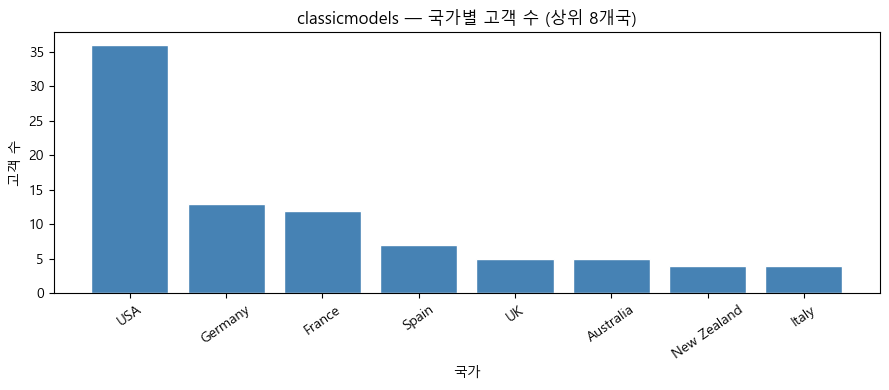

In [6]:
# ── 차트 1: 국가별 고객 수 ─────────────────────────────────────
countries = [row['country'] for row in rows]
counts    = [row['customer_count'] for row in rows]

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(countries, counts, color='steelblue', edgecolor='white')
ax.set_title('classicmodels — 국가별 고객 수 (상위 8개국)')
ax.set_xlabel('국가')
ax.set_ylabel('고객 수')
ax.tick_params(axis='x', rotation=35)
fig.tight_layout()
plt.show()

In [7]:
# 제품 라인별 매출 (JOIN 맛보기)
sql_revenue = """
SELECT 
    p.productLine
    , ROUND(SUM(od.quantityOrdered * od.priceEach), 2) AS revenue
FROM orderdetails od 
INNER JOIN products p ON od.productCode = p.productCode
GROUP BY p.productLine
ORDER BY revenue DESC
;
"""

cols, revenue_rows = run_query(CLASSIC_DB, sql_revenue)
for row in revenue_rows:
    print(f"{row['productLine']:25s}  {row['revenue']:>12,.0f}")

Classic Cars                  3,853,922
Vintage Cars                  1,797,560
Motorcycles                   1,121,426
Trucks and Buses              1,024,114
Planes                          954,638
Ships                           663,998
Trains                          188,533


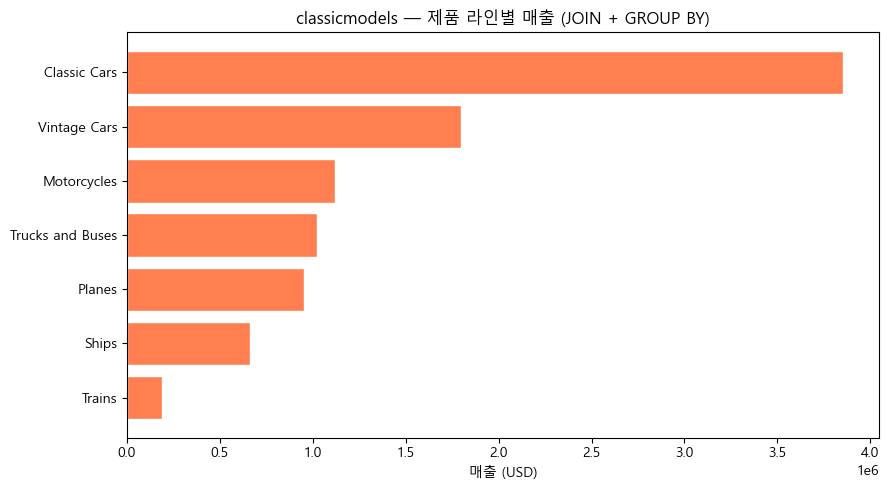

In [8]:
# ── 차트 2: 제품 라인별 매출 (가로 막대) ────────────────────────
lines    = [row['productLine'] for row in revenue_rows]
revenues = [row['revenue'] for row in revenue_rows]

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(lines, revenues, color='coral', edgecolor='white')
ax.set_title('classicmodels — 제품 라인별 매출 (JOIN + GROUP BY)')
ax.set_xlabel('매출 (USD)')
ax.invert_yaxis()          # 매출 1위가 위로 오도록
fig.tight_layout()
plt.show()

---
## 3. 새 DB 생성 + CRUD (`datasets/day04_shop.db`)

가상의 **미니 쇼핑몰** 스키마를 만들고 Create · Read · Update · Delete 를 연습합니다.

```
categories ──< products
customers  ──< orders ──< order_items >── products
```

In [10]:
# 기존 연습 DB가 있으면 삭제 후 새로 생성
if PRACTICE_DB.exists():
    PRACTICE_DB.unlink()

conn = sqlite3.connect(PRACTICE_DB)
cur = conn.cursor()

# ── CREATE (테이블 생성) ───────────────────────────────────────
cur.executescript("""
CREATE TABLE categories (
    category_id   INTEGER PRIMARY KEY,
    category_name TEXT NOT NULL
);

CREATE TABLE products (
    product_id   INTEGER PRIMARY KEY,
    product_name TEXT NOT NULL,
    category_id  INTEGER NOT NULL,
    price        REAL NOT NULL,
    FOREIGN KEY (category_id) REFERENCES categories(category_id)
);

CREATE TABLE customers (
    customer_id   INTEGER PRIMARY KEY,
    customer_name TEXT NOT NULL,
    city          TEXT NOT NULL
);

CREATE TABLE orders (
    order_id    INTEGER PRIMARY KEY,
    customer_id INTEGER NOT NULL,
    order_date  TEXT NOT NULL,
    FOREIGN KEY (customer_id) REFERENCES customers(customer_id)
);

CREATE TABLE order_items (
    item_id    INTEGER PRIMARY KEY,
    order_id   INTEGER NOT NULL,
    product_id INTEGER NOT NULL,
    quantity   INTEGER NOT NULL,
    FOREIGN KEY (order_id)   REFERENCES orders(order_id),
    FOREIGN KEY (product_id) REFERENCES products(product_id)
);
""")
conn.commit()
print('테이블 생성 완료')

PermissionError: [WinError 32] 다른 프로세스가 파일을 사용 중이기 때문에 프로세스가 액세스 할 수 없습니다: '..\\..\\datasets\\day04_shop.db'

In [12]:
# ── INSERT (샘플 데이터 삽입) ───────────────────────────────────
sample_data = [
    "INSERT INTO categories VALUES (1,'음료'), (2,'과자'), (3,'생활용품');",
    """INSERT INTO products VALUES
        (101,'아메리카노',1,4500),
        (102,'녹차',1,4000),
        (103,'초코칩쿠키',2,2500),
        (104,'감자칩',2,1800),
        (105,'물티슈',3,3200),
        (106,'세제',3,8900);""",
    "INSERT INTO customers VALUES (1,'김민수','서울'), (2,'이영희','부산'), (3,'박지훈','대구');",
    "INSERT INTO orders VALUES (1001,1,'2026-06-01'), (1002,2,'2026-06-03'), (1003,1,'2026-06-05');",
    """INSERT INTO order_items VALUES
        (1,1001,101,2), (2,1001,103,1),
        (3,1002,102,3), (4,1002,104,2),
        (5,1003,105,1), (6,1003,106,1), (7,1003,101,1);"""
]

for sql in sample_data:
    cur.execute(sql)
conn.commit()
print('샘플 데이터 삽입 완료')

IntegrityError: UNIQUE constraint failed: categories.category_id

In [17]:
# ── READ (조회) ────────────────────────────────────────────────
cur.execute('SELECT * FROM products')
print('=== products ===')
for row in cur.fetchall():
    print(row)

=== products ===
(101, '아메리카노', 1, 4500.0)
(102, '녹차', 1, 4000.0)
(103, '초코칩쿠키', 2, 2500.0)
(104, '감자칩', 2, 1800.0)
(105, '물티슈', 3, 3200.0)
(106, '세제', 3, 8900.0)


In [19]:
# ── UPDATE (수정) ──────────────────────────────────────────────
cur.execute("UPDATE products SET price = price * 1.1 WHERE category_id = 1")
conn.commit()

cur.execute("SELECT product_name, price FROM products WHERE category_id = 1")
print('음료 가격 10% 인상 후:')
for row in cur.fetchall():
    print(row)

음료 가격 10% 인상 후:
('아메리카노', 5445.0)
('녹차', 4840.0)


In [20]:
# ── DELETE (삭제) ──────────────────────────────────────────────
cur.execute("DELETE FROM order_items WHERE product_id = 104")
conn.commit()

cur.execute('SELECT * FROM order_items')
print('감자칩(104) 주문 삭제 후 order_items:')
for row in cur.fetchall():
    print(row)

conn.close()

감자칩(104) 주문 삭제 후 order_items:
(1, 1001, 101, 2)
(2, 1001, 103, 1)
(3, 1002, 102, 3)
(5, 1003, 105, 1)
(6, 1003, 106, 1)
(7, 1003, 101, 1)


---
## 4. Python에서 JOIN · 서브쿼리 실행

방금 만든 `day04_shop.db`로 JOIN과 서브쿼리를 실행합니다.

In [21]:
conn = sqlite3.connect(PRACTICE_DB)
cur = conn.cursor()

In [22]:
conn = sqlite3.connect(PRACTICE_DB)
conn.row_factory = sqlite3.Row
cur = conn.cursor()

# ── JOIN: 고객 · 주문 · 주문상세 · 상품 ─────────────────────────
sql_join = """
SELECT c.customer_name,
       o.order_id,
       p.product_name,
       oi.quantity,
       p.price,
       (oi.quantity * p.price) AS line_total
FROM customers c
INNER JOIN orders o       ON c.customer_id = o.customer_id
INNER JOIN order_items oi ON o.order_id    = oi.order_id
INNER JOIN products p     ON oi.product_id = p.product_id
ORDER BY o.order_id, p.product_name
"""

cur.execute(sql_join)
join_rows = cur.fetchall()

print('=== JOIN 결과: 주문 상세 내역 ===')
for row in join_rows:
    print(f"{row['customer_name']:6s} | 주문 {row['order_id']} | "
          f"{row['product_name']:10s} x{row['quantity']} = {row['line_total']:,.0f}원")

=== JOIN 결과: 주문 상세 내역 ===
김민수    | 주문 1001 | 아메리카노      x2 = 10,890원
김민수    | 주문 1001 | 초코칩쿠키      x1 = 2,500원
이영희    | 주문 1002 | 녹차         x3 = 14,520원
김민수    | 주문 1003 | 물티슈        x1 = 3,200원
김민수    | 주문 1003 | 세제         x1 = 8,900원
김민수    | 주문 1003 | 아메리카노      x1 = 5,445원


In [23]:
# ── JOIN + GROUP BY: 카테고리별 판매 수량 ───────────────────────
sql_category_sales = """
SELECT cat.category_name,
       SUM(oi.quantity) AS total_qty
FROM order_items oi
INNER JOIN products p  ON oi.product_id  = p.product_id
INNER JOIN categories cat ON p.category_id = cat.category_id
GROUP BY cat.category_name
ORDER BY total_qty DESC
"""

cur.execute(sql_category_sales)
cat_rows = cur.fetchall()

print('=== 카테고리별 판매 수량 ===')
for row in cat_rows:
    print(f"{row['category_name']:8s}  {row['total_qty']}개")

=== 카테고리별 판매 수량 ===
음료        6개
생활용품      2개
과자        1개


In [24]:
# ── 서브쿼리: 평균 가격보다 비싼 상품 ────────────────────────────
sql_sub_avg = """
SELECT product_name, price
FROM products
WHERE price > (SELECT AVG(price) FROM products)
ORDER BY price DESC
"""

cur.execute(sql_sub_avg)
print('=== 평균 가격보다 비싼 상품 (단일 행 서브쿼리) ===')
for row in cur.fetchall():
    print(dict(row))

=== 평균 가격보다 비싼 상품 (단일 행 서브쿼리) ===
{'product_name': '세제', 'price': 8900.0}
{'product_name': '아메리카노', 'price': 5445.0}
{'product_name': '녹차', 'price': 4840.0}


In [25]:
# ── 서브쿼리 IN: '음료' 카테고리 상품이 포함된 주문 번호 ─────────
sql_sub_in = """
SELECT DISTINCT o.order_id, c.customer_name, o.order_date
FROM orders o
INNER JOIN customers c ON o.customer_id = c.customer_id
WHERE o.order_id IN (
    SELECT oi.order_id
    FROM order_items oi
    WHERE oi.product_id IN (
        SELECT product_id FROM products WHERE category_id = 1
    )
)
ORDER BY o.order_id
"""


cur.execute(sql_sub_in)
print('=== 음료를 주문한 고객의 주문 (다중 행 서브쿼리 IN) ===')
for row in cur.fetchall():
    print(dict(row))

conn.close()

=== 음료를 주문한 고객의 주문 (다중 행 서브쿼리 IN) ===
{'order_id': 1001, 'customer_name': '김민수', 'order_date': '2026-06-01'}
{'order_id': 1002, 'customer_name': '이영희', 'order_date': '2026-06-03'}
{'order_id': 1003, 'customer_name': '김민수', 'order_date': '2026-06-05'}


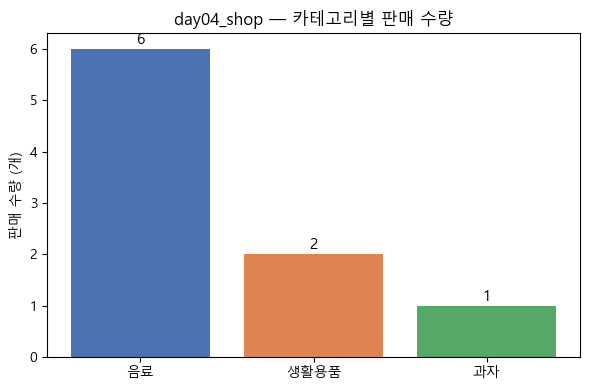

In [26]:
# ── 보너스 시각화: 연습 DB 카테고리별 판매 수량 ─────────────────
conn = sqlite3.connect(PRACTICE_DB)
conn.row_factory = sqlite3.Row
cur = conn.cursor()
cur.execute(sql_category_sales)
cat_rows = cur.fetchall()
conn.close()

labels = [r['category_name'] for r in cat_rows]
values = [r['total_qty'] for r in cat_rows]

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(labels, values, color=['#4C72B0', '#DD8452', '#55A868'])
ax.set_title('day04_shop — 카테고리별 판매 수량')
ax.set_ylabel('판매 수량 (개)')
for i, v in enumerate(values):
    ax.text(i, v + 0.1, str(v), ha='center', fontsize=11)
fig.tight_layout()
plt.show()

---
## 마무리 정리

| 단계 | Python 코드 | SQL 개념 |
|------|-------------|----------|
| 연결 | `sqlite3.connect(path)` | DB 접속 |
| 조회 | `cursor.execute()` + `fetchall()` | SELECT |
| 삽입 | `INSERT` + `commit()` | CREATE 데이터 |
| 수정 | `UPDATE` + `commit()` | UPDATE |
| 삭제 | `DELETE` + `commit()` | DELETE |
| 분석 | JOIN · 서브쿼리 SQL을 Python에서 실행 | JOIN / Subquery |
| 시각화 | `fig, ax = plt.subplots()` | — |